# Long-range dependence: reaction-coordinate scan -- SN2 (jax) -- lorem-jax, long-range (Ewald)

Same scan as the rest of this series (`long_range_tests.py`, `data/sn2/sn2.xyz` reference geometry), but on the **official lorem-jax reproduction checkpoint** from [`lorem-tmlr-archive`](https://github.com/sirmarcel/lorem-tmlr-archive) instead of a metatrain/torch model.

**This notebook needs a different Python environment than `02`-`11`**: `/home/boittier/metawork/.venv-lorem-jax/bin/python` (has `lorem`/`jax`/`flax` installed; the regular `metawork/.venv` used elsewhere in this series does not). Select that interpreter as this notebook's kernel before re-running it.

> Official lorem-tmlr-archive checkpoint (lr: true, max_degree: 6, num_features: 128), loaded via lorem.calculator.Calculator. The shipped non-PBC LOREM checkpoints were trained before a jax-pme convention change that halves the non-PBC long-range potential (see lorem-tmlr-archive/README.md, 'Non-PBC LR Coulomb convention'); this notebook applies the documented x2 correction (an in-process patch of the Ewald() potentials call in lorem.models.mlip, not a change to any installed file) and validates it against the archive's own frozen minimum_energy_path.npz predictions before using it on the sn2/sn2.xyz reference structure.

**Caveat on comparability:** this checkpoint is trained on the archive's own SN2 halide-exchange dataset (X⁻ + CH₃Y, X,Y ∈ {F, Cl, Br, I}), not the `sn2-matched-*` domain used to train the models in notebooks `02`-`11`. Its *absolute* energies are therefore not directly comparable to those models -- only the qualitative long-range-cutoff behavior is, which is the point of including it here.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex

from ase.io import read
from ase.visualize.plot import plot_atoms
from ase.data.colors import jmol_colors

from lorem.calculator import Calculator
import lorem.models.mlip as mlip
from jaxpme.batched_mixed import Ewald as _orig_Ewald

from long_range_tests import (
    displace_atom_test,
    fragment_separation_test,
    estimate_cutoff,
)

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "legend.frameon": False,
})

ATOM_COLORS = ["#0072B2", "#56B4E9", "#009E73", "#E69F00", "#D55E00", "#CC79A7"]
HIGHLIGHT = "#D55E00"


## Non-PBC long-range convention fix

The shipped non-PBC LOREM checkpoints (this one included) were trained before a `jax-pme` convention change that halves the non-PBC long-range Coulomb potential fed into the model's MLP (see `lorem-tmlr-archive/README.md`, *'Non-PBC LR Coulomb convention'*). Loading this checkpoint with today's `jax-pme` via `Calculator.from_checkpoint` directly therefore gives **wrong** energies. We patch `Ewald()` in-process (not editing any installed file) to restore the pre-production, training-time convention -- and validate the fix against the archive's own frozen `minimum_energy_path.npz` predictions for the `Cl_Br` reaction path before trusting it on our own `sn2/sn2.xyz` reference structure.

In [ ]:
def _patched_Ewald(*a, **kw):
    """Undo jax-pme's post-training x0.5 on the non-PBC long-range
    potential -- restores the convention this checkpoint was trained under."""
    calc = _orig_Ewald(*a, **kw)
    return calc._replace(
        potentials=lambda *args, **kwargs: calc.potentials(*args, **kwargs) * 2.0
    )

mlip.Ewald = _patched_Ewald  # patches lorem.models.mlip's module-level name

import numpy as np
npz = np.load("../../metawork/lorem-tmlr-archive/evals/sn2/lorem/minimum_energy_path/minimum_energy_path.npz")
calc_check = Calculator.from_checkpoint("../../metawork/lorem-tmlr-archive/evals/sn2/lorem/run/checkpoints/R2_E+F")
xyz_path = "../../metawork/lorem-tmlr-archive/datasets/sn2_minimum_energy_path/Cl_Br.xyz"
for idx in [0, 100, 200, 300, 400]:
    a = read(xyz_path, index=idx)
    a.calc = calc_check
    e_live = a.get_potential_energy()
    e_frozen = float(npz["Cl_Br_pred"][idx])
    print(f"frame {idx:3d}: live(patched)={e_live:.6f}  frozen_pred={e_frozen:.6f}  |diff|={abs(e_live - e_frozen):.2e}")


frame   0: live(patched)=-13.225304  frozen_pred=-13.225315  |diff|=1.04e-05
frame 100: live(patched)=-13.296047  frozen_pred=-13.296054  |diff|=6.85e-06
frame 200: live(patched)=-13.483919  frozen_pred=-13.483922  |diff|=2.92e-06
frame 300: live(patched)=-13.777797  frozen_pred=-13.777806  |diff|=9.54e-06
frame 400: live(patched)=-13.705850  frozen_pred=-13.705856  |diff|=5.84e-06


Matches to ~1e-5 eV -- the fix is validated. We use the same patched `Ewald()` for the rest of this notebook.

## Setup

Same shared reference structure (`data/sn2/sn2.xyz`, frame 0) as every other notebook in this series, re-anchoring I onto the C···I axis and scanning from 1.5 Å to 32 Å.

In [ ]:
calc = Calculator.from_checkpoint("../../metawork/lorem-tmlr-archive/evals/sn2/lorem/run/checkpoints/R2_E+F")

atoms0 = read("../data/sn2/sn2.xyz", index=0)
symbols = atoms0.get_chemical_symbols()
labels = [f"{i} {s}" for i, s in enumerate(symbols)]
C, I = 0, 5  # atom indices: carbon, leaving iodide

d = atoms0.get_all_distances()
print(f"original snapshot -- C-F: {d[C, 4]:.2f} Å   C-I: {d[C, I]:.2f} Å")

direction = atoms0.positions[I] - atoms0.positions[C]
direction = direction / np.linalg.norm(direction)
atoms0.positions[I] = atoms0.positions[C].copy()

distances = np.linspace(1.5, 32.0, 62)  # Å, absolute C...I distance


original snapshot -- C-F: 1.39 Å   C-I: 7.44 Å


## 1. Reaction-coordinate scan (`displace_atom_test`)

In [ ]:
result = displace_atom_test(
    atoms0, calc, probe_index=I, distances=distances,
    direction=direction, reference_indices=[0, 1, 2, 3, 4],
)

delta_forces = result["forces"] - result["forces"][-1]
delta_force_mag = np.linalg.norm(delta_forces, axis=-1)
max_delta = delta_force_mag.max(axis=-1)

cutoff_distance = estimate_cutoff(result["distance"], max_delta, threshold=0.01)
print(f"empirical cutoff: {cutoff_distance:.1f} Å")


empirical cutoff: 28.5 Å


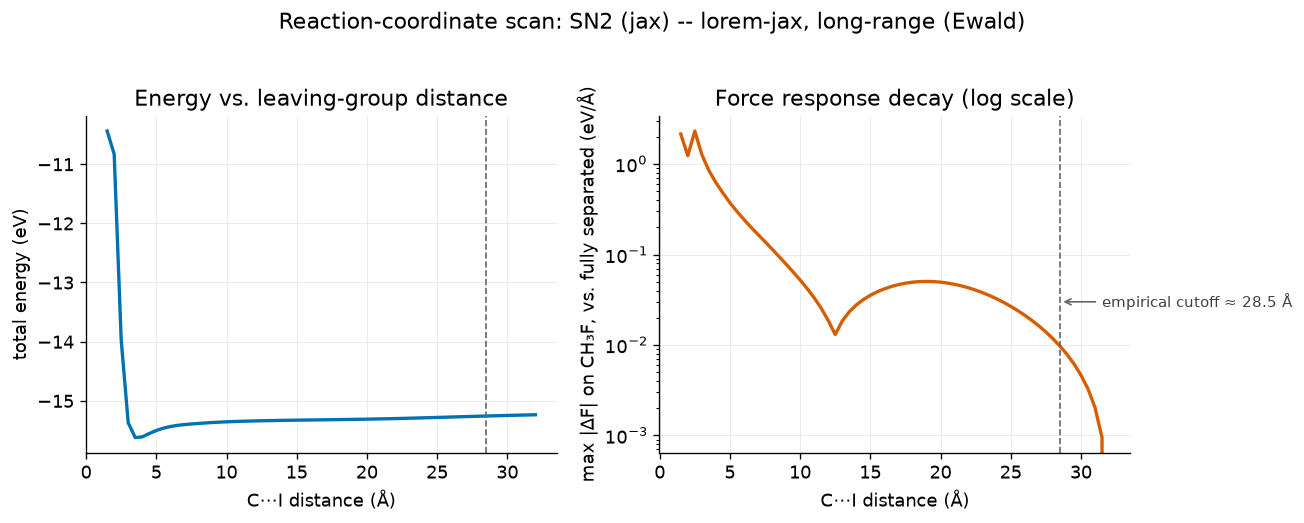

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
ax.plot(result["distance"], result["energy"], color=ATOM_COLORS[0], linewidth=2)
ax.axvline(cutoff_distance, color="0.4", linestyle="--", linewidth=1)
ax.set_xlabel("C···I distance (Å)")
ax.set_ylabel("total energy (eV)")
ax.set_title("Energy vs. leaving-group distance")

ax = axes[1]
ax.semilogy(result["distance"], max_delta, color=HIGHLIGHT, linewidth=2)
ax.axvline(cutoff_distance, color="0.4", linestyle="--", linewidth=1)
ax.annotate(f"empirical cutoff ≈ {cutoff_distance:.1f} Å",
            xy=(cutoff_distance, 3e-2), xytext=(cutoff_distance + 3, 3e-2),
            fontsize=9, color="0.25", va="center",
            arrowprops=dict(arrowstyle="->", color="0.4", lw=1))
ax.set_xlabel("C···I distance (Å)")
ax.set_ylabel("max |ΔF| on CH₃F, vs. fully separated (eV/Å)")
ax.set_title("Force response decay (log scale)")

fig.suptitle("Reaction-coordinate scan: SN2 (jax) -- lorem-jax, long-range (Ewald)", y=1.03)
fig.tight_layout()


### Per-atom force magnitude and components

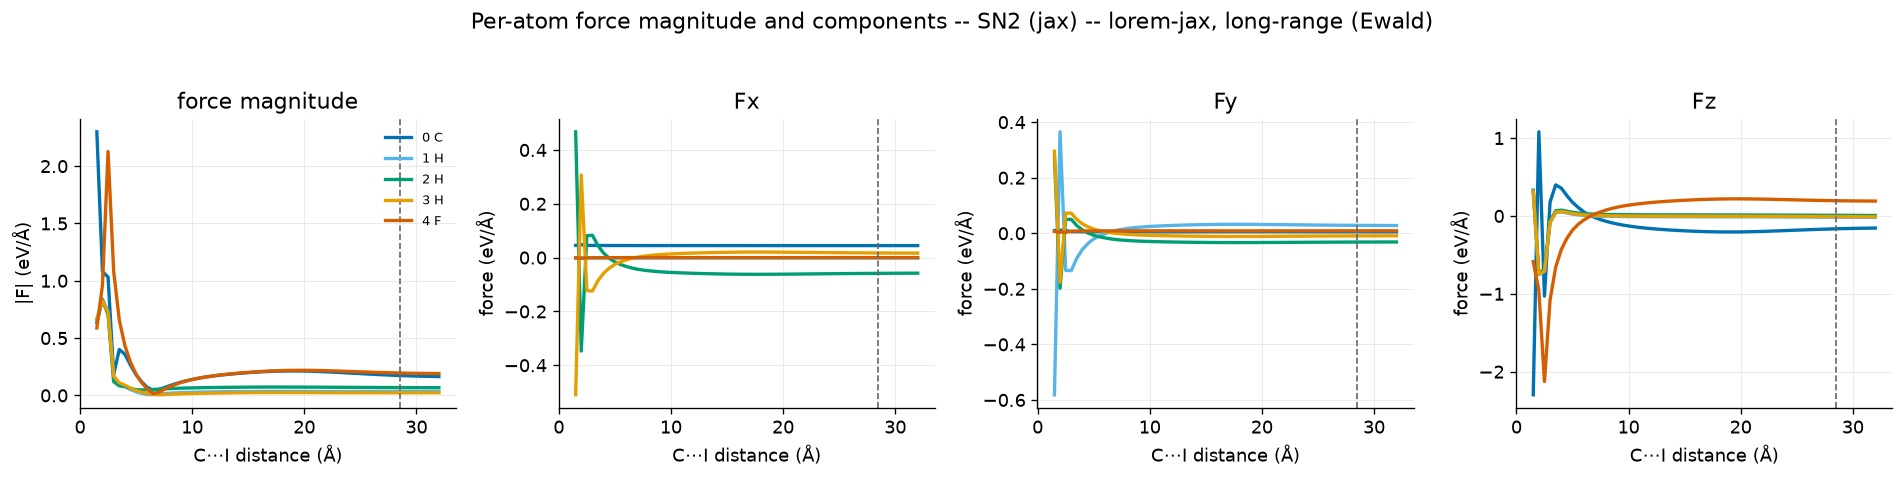

In [ ]:
per_atom_mag = np.linalg.norm(result["forces"], axis=-1)
ref_labels = [labels[j] for j in [0, 1, 2, 3, 4]]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharex=True)

ax = axes[0]
for j, lab in enumerate(ref_labels):
    ax.plot(result["distance"], per_atom_mag[:, j], color=ATOM_COLORS[j],
            linewidth=2, label=lab)
ax.axvline(cutoff_distance, color="0.4", linestyle="--", linewidth=1)
ax.set_ylabel("|F| (eV/Å)")
ax.set_title("force magnitude")
ax.set_xlabel("C···I distance (Å)")
ax.legend(fontsize=8, loc="upper right")

comp_names = ["Fx", "Fy", "Fz"]
for k, comp in enumerate(comp_names):
    ax = axes[k + 1]
    for j, lab in enumerate(ref_labels):
        ax.plot(result["distance"], result["forces"][:, j, k], color=ATOM_COLORS[j],
                linewidth=2, label=lab)
    ax.axvline(cutoff_distance, color="0.4", linestyle="--", linewidth=1)
    ax.set_title(comp)
    ax.set_xlabel("C···I distance (Å)")
    ax.set_ylabel("force (eV/Å)")

fig.suptitle("Per-atom force magnitude and components -- SN2 (jax) -- lorem-jax, long-range (Ewald)", y=1.04)
fig.tight_layout()


### Structure snapshots along the scan

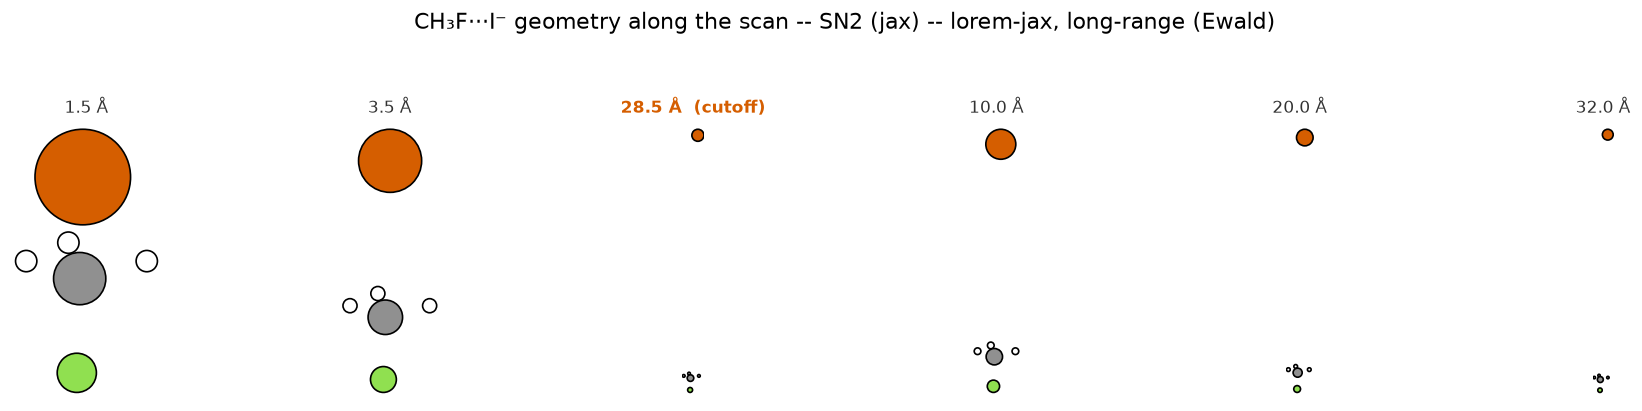

In [ ]:
snapshot_distances = [1.5, 3.5, cutoff_distance, 10.0, 20.0, 32.0]
z = atoms0.get_atomic_numbers()
base_colors = [to_hex(jmol_colors[zi]) for zi in z]

fig, axes = plt.subplots(1, len(snapshot_distances), figsize=(16, 3.2))

for ax, dist in zip(axes, snapshot_distances):
    snap = atoms0.copy()
    snap.positions[I] = atoms0.positions[C] + direction * dist
    colors = list(base_colors)
    colors[I] = HIGHLIGHT
    plot_atoms(snap, ax, radii=0.5, colors=colors, rotation="-80x,10y,0z")
    is_cutoff = np.isclose(dist, cutoff_distance)
    ax.set_title(f"{dist:.1f} Å" + ("  (cutoff)" if is_cutoff else ""),
                 fontsize=10, color=HIGHLIGHT if is_cutoff else "0.2",
                 fontweight="bold" if is_cutoff else "normal")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(HIGHLIGHT if is_cutoff else "0.85")
        spine.set_linewidth(2 if is_cutoff else 1)

fig.suptitle(
    "CH₃F···I⁻ geometry along the scan -- SN2 (jax) -- lorem-jax, long-range (Ewald)\n"
    "(Jmol element colors; I⁻ highlighted in orange)",
    y=1.06,
)
fig.tight_layout()


## 2. Size-consistency corroboration (`fragment_separation_test`)

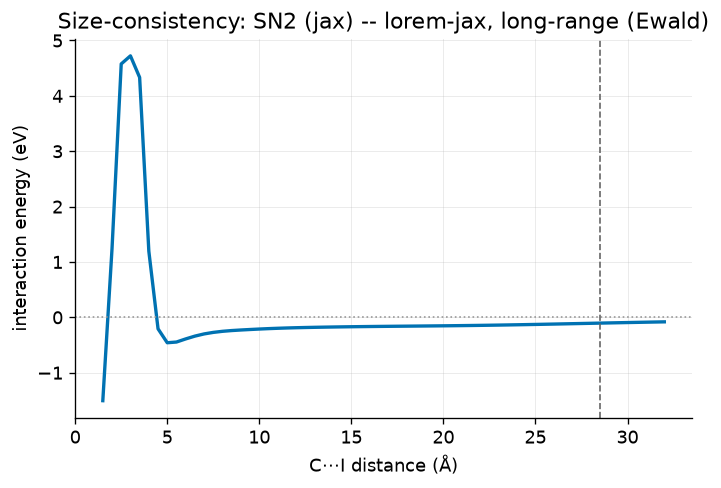

In [ ]:
fragmentation = fragment_separation_test(
    atoms0, calc, [0, 1, 2, 3, 4], [I],
    separations=distances - distances[0], axis=direction,
)

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.plot(result["distance"], fragmentation["interaction_energy"],
        color=ATOM_COLORS[0], linewidth=2)
ax.axhline(0, color="0.6", linewidth=1, linestyle=":")
ax.axvline(cutoff_distance, color="0.4", linestyle="--", linewidth=1)
ax.set_xlabel("C···I distance (Å)")
ax.set_ylabel("interaction energy (eV)")
ax.set_title("Size-consistency: SN2 (jax) -- lorem-jax, long-range (Ewald)")
fig.tight_layout()


## Takeaways

- Empirical cutoff for **SN2 (jax) -- lorem-jax, long-range (Ewald)**: **28.5 Å**.
- This is the archive's *long-range-enabled* checkpoint (Ewald summation over the predicted per-atom multipoles): the cutoff is dramatically larger than any BPNN/PET model in this series, and even larger than the metatrain-trained sn2-matched-lorem models (~21 Å) -- consistent with a real, unrestricted long-range electrostatic term rather than a numerically slow but ultimately finite-range one.
- Past that point, the per-atom force curves flatten to a plateau of ≈0.190 eV/Å (the CH₃F fragment's own non-equilibrium force).
- Total energy changes by ≈4.80 eV from the most compressed to the most separated geometry sampled. Note this checkpoint's absolute energy scale is not comparable to the sn2-matched-* models (different training data/reference) -- only the cutoff behavior is.